# 02 - Hypothesis Testing

**Input:** `student_processed.csv` (created in `01_preprocessing_eda.ipynb`)

This notebook runs three formal statistical tests on the Student Performance data, each with assumption checks, an effect size, and a robustness check:

| # | Test | Question |
|---|---|---|
| 1 | One-sample t-test | Is the mean final grade (`G3`) different from 10? |
| 2 | Two-sample Welch t-test | Do urban and rural students differ in mean `G3`? |
| 3 | Chi-square test of independence | Are wanting higher education and being in a romantic relationship independent? |

Significance level: **alpha = 0.05** for all tests.

**Encoding reminder (from notebook 01):** `address`: 1 = urban, 0 = rural; `higher` and `romantic`: 1 = yes, 0 = no.

## 1. Setup & Data Loading

In [4]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

ALPHA = 0.05
RANDOM_STATE = 42

DATA_PATH = Path("../data/student_processed.csv")


df = pd.read_csv(DATA_PATH)
print(f"Loaded {DATA_PATH.resolve()}")
print(f"Dataset shape: {df.shape}")

required = ["G3", "address", "higher", "romantic"]
assert all(c in df.columns for c in required), "Required columns are missing"
assert df[required].notna().all().all(), "Missing values in required columns"
df[required].describe().T

Loaded A:\US\Semestr5\Szkoła Zimowa\Projekt\Repo\Data-science\data\student_processed.csv
Dataset shape: (395, 44)


,count,mean,std,min,25%,50%,75%,max
G3,395.0,10.415190,4.581443,0.0,8.0,11.0,14.0,20.0
address,395.0,0.777215,0.416643,0.0,1.0,1.0,1.0,1.0
higher,395.0,0.949367,0.219525,0.0,1.0,1.0,1.0,1.0
romantic,395.0,0.334177,0.472300,0.0,0.0,0.0,1.0,1.0


### Helper functions

Small reusable helpers for the decision rule and effect sizes.

In [5]:
def decision(p_value, alpha=ALPHA):
    """Return a readable decision for a given p-value."""
    if p_value < alpha:
        return f"p = {p_value:.4g} < {alpha}: reject H0"
    return f"p = {p_value:.4g} >= {alpha}: fail to reject H0"


def cohens_d_two_sample(a, b):
    """Cohen's d using the pooled standard deviation."""
    na, nb = len(a), len(b)
    pooled_sd = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / pooled_sd


def effect_label(d):
    """Conventional interpretation of |d| (Cohen)."""
    d = abs(d)
    if d < 0.2:
        return "negligible"
    if d < 0.5:
        return "small"
    if d < 0.8:
        return "medium"
    return "large"

## 2. Test 1 - One-Sample t-test

**Question:** Does the average final grade differ from the reference value of 10 (the pass threshold on the 0-20 scale)?

- **H0:** mean(G3) = 10
- **H1:** mean(G3) != 10 (two-sided)

### 2.1 Assumption check
The t-test assumes approximately normal data, or a large sample (n = 395, so the central limit theorem applies). We still inspect the distribution.

n = 395, mean = 10.415, std = 4.581, skewness = -0.733
Shapiro-Wilk normality test: W = 0.9287, p = 8.836e-13


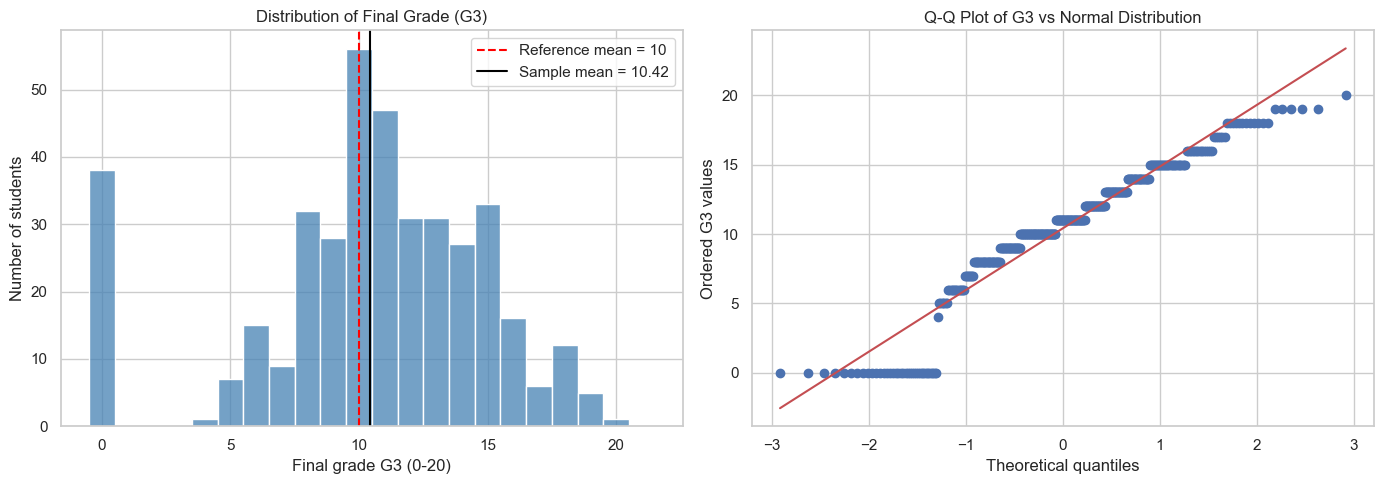

In [6]:
g3 = df["G3"]
REFERENCE_MEAN = 10.0

shapiro_stat, shapiro_p = stats.shapiro(g3)
print(f"n = {len(g3)}, mean = {g3.mean():.3f}, std = {g3.std():.3f}, skewness = {g3.skew():.3f}")
print(f"Shapiro-Wilk normality test: W = {shapiro_stat:.4f}, p = {shapiro_p:.4g}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(g3, bins=21, binrange=(0, 21), discrete=True, kde=False, color="steelblue", ax=axes[0])
axes[0].axvline(REFERENCE_MEAN, color="red", linestyle="--", label=f"Reference mean = {REFERENCE_MEAN:.0f}")
axes[0].axvline(g3.mean(), color="black", linestyle="-", label=f"Sample mean = {g3.mean():.2f}")
axes[0].set_title("Distribution of Final Grade (G3)")
axes[0].set_xlabel("Final grade G3 (0-20)")
axes[0].set_ylabel("Number of students")
axes[0].legend()

stats.probplot(g3, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of G3 vs Normal Distribution")
axes[1].set_xlabel("Theoretical quantiles")
axes[1].set_ylabel("Ordered G3 values")

plt.tight_layout()
plt.show()

The Shapiro-Wilk test rejects exact normality, mainly because of the spike of students with `G3 = 0`. With n = 395 the t-test is still robust to this, and we additionally run a non-parametric Wilcoxon test below as a check.

### 2.2 Test

In [7]:
t_stat, p_val_1 = stats.ttest_1samp(g3, REFERENCE_MEAN)
ci_1 = stats.ttest_1samp(g3, REFERENCE_MEAN).confidence_interval(confidence_level=1 - ALPHA)
cohens_d_1 = (g3.mean() - REFERENCE_MEAN) / g3.std(ddof=1)

print("=== TEST 1: One-sample t-test ===")
print(f"Sample mean:        {g3.mean():.4f}")
print(f"t-statistic:        {t_stat:.4f} (df = {len(g3) - 1})")
print(f"p-value:            {p_val_1:.4g}")
print(f"95% CI for mean:    [{ci_1.low:.4f}, {ci_1.high:.4f}]")
print(f"Cohen's d:          {cohens_d_1:.4f} ({effect_label(cohens_d_1)})")
print(f"Decision:           {decision(p_val_1)}")

=== TEST 1: One-sample t-test ===
Sample mean:        10.4152
t-statistic:        1.8011 (df = 394)
p-value:            0.07245
95% CI for mean:    [9.9620, 10.8684]
Cohen's d:          0.0906 (negligible)
Decision:           p = 0.07245 >= 0.05: fail to reject H0


In [8]:
# Robustness checks: Wilcoxon signed-rank test, and the t-test without the G3 = 0 group
wilcoxon_stat, wilcoxon_p = stats.wilcoxon(g3 - REFERENCE_MEAN)
g3_nonzero = g3[g3 > 0]
t_nz, p_nz = stats.ttest_1samp(g3_nonzero, REFERENCE_MEAN)

robustness_1 = pd.DataFrame({
    "check": ["Wilcoxon signed-rank (all students)", "t-test excluding G3 = 0"],
    "n": [len(g3), len(g3_nonzero)],
    "sample_mean": [g3.mean(), g3_nonzero.mean()],
    "p_value": [wilcoxon_p, p_nz],
    "decision": [decision(wilcoxon_p), decision(p_nz)],
}).set_index("check")
robustness_1.round(4)

,n,sample_mean,p_value,decision
check,,,,
Wilcoxon signed-rank (all students),395,10.4152,0.0013,p = 0.001286 < 0.05: reject H0
t-test excluding G3 = 0,357,11.5238,0.0000,p = 2.493e-17 < 0.05: reject H0


**Interpretation:** the sample mean (about 10.4) is not significantly different from 10 (p is about 0.07), and the effect size is negligible. However, the conclusion is **not robust**: the Wilcoxon test (which is sensitive to the skewed shape and tests the centre of the distribution rather than the mean) and the t-test without the `G3 = 0` group both reject H0. The result therefore depends on how the dropout-like zero grades are treated: with them included the mean is pulled down towards 10, without them the typical student scores clearly above 10 (mean about 11.5).

## 3. Test 2 - Two-Sample Welch t-test (Urban vs Rural)

**Question:** Is the mean final grade different for students living in urban and rural areas?

- **H0:** mean(G3 | urban) = mean(G3 | rural)
- **H1:** mean(G3 | urban) != mean(G3 | rural) (two-sided)

Welch's version is used because it does not assume equal variances.

### 3.1 Group description & assumption checks

,n,mean,std,median
Urban,307,10.674,4.563,11.0
Rural,88,9.511,4.556,10.0


Levene test for equal variances: statistic = 0.0395, p = 0.8426
-> Welch's t-test is appropriate either way (it does not assume equal variances).


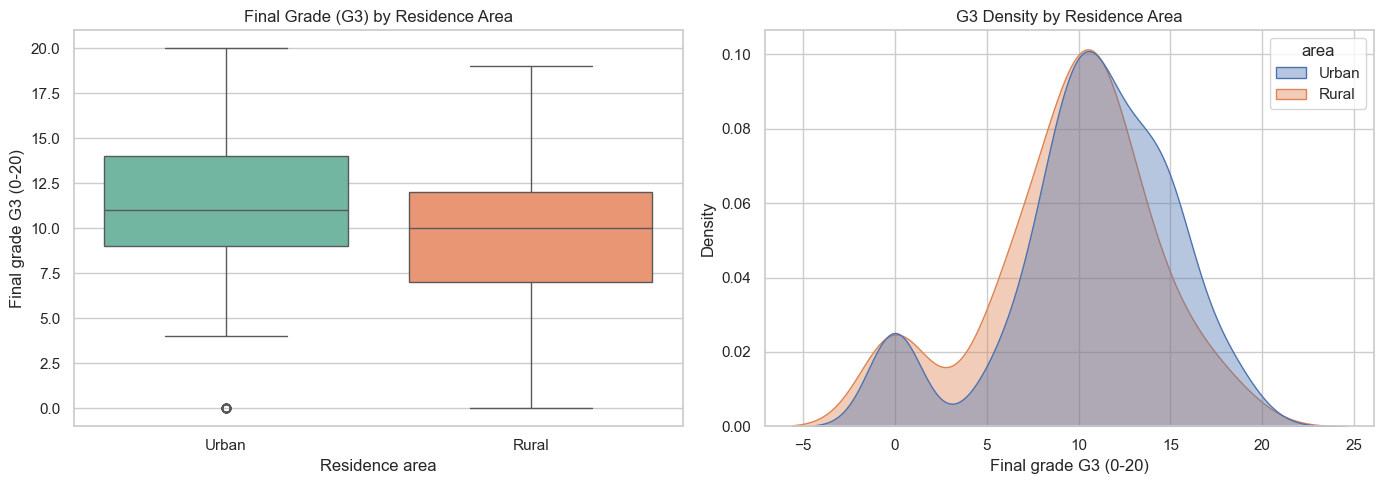

In [9]:
urban = df.loc[df["address"] == 1, "G3"]
rural = df.loc[df["address"] == 0, "G3"]

group_summary = pd.DataFrame({
    "n": [len(urban), len(rural)],
    "mean": [urban.mean(), rural.mean()],
    "std": [urban.std(), rural.std()],
    "median": [urban.median(), rural.median()],
}, index=["Urban", "Rural"])
display(group_summary.round(3))

levene_stat, levene_p = stats.levene(urban, rural)
print(f"Levene test for equal variances: statistic = {levene_stat:.4f}, p = {levene_p:.4g}")
print("-> Welch's t-test is appropriate either way (it does not assume equal variances).")

plot_df = df.assign(area=df["address"].map({1: "Urban", 0: "Rural"}))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=plot_df, x="area", y="G3", order=["Urban", "Rural"], palette="Set2", ax=axes[0])
axes[0].set_title("Final Grade (G3) by Residence Area")
axes[0].set_xlabel("Residence area")
axes[0].set_ylabel("Final grade G3 (0-20)")

sns.kdeplot(data=plot_df, x="G3", hue="area", common_norm=False, fill=True, alpha=0.4, ax=axes[1])
axes[1].set_title("G3 Density by Residence Area")
axes[1].set_xlabel("Final grade G3 (0-20)")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

### 3.2 Test

In [10]:
res_2 = stats.ttest_ind(urban, rural, equal_var=False)
ci_2 = res_2.confidence_interval(confidence_level=1 - ALPHA)
d_2 = cohens_d_two_sample(urban, rural)

print("=== TEST 2: Welch two-sample t-test ===")
print(f"Urban mean: {urban.mean():.4f} | Rural mean: {rural.mean():.4f}")
print(f"Mean difference (urban - rural): {urban.mean() - rural.mean():.4f}")
print(f"t-statistic:        {res_2.statistic:.4f} (df = {res_2.df:.1f})")
print(f"p-value:            {res_2.pvalue:.4g}")
print(f"95% CI for diff:    [{ci_2.low:.4f}, {ci_2.high:.4f}]")
print(f"Cohen's d:          {d_2:.4f} ({effect_label(d_2)})")
print(f"Decision:           {decision(res_2.pvalue)}")

=== TEST 2: Welch two-sample t-test ===
Urban mean: 10.6743 | Rural mean: 9.5114
Mean difference (urban - rural): 1.1629
t-statistic:        2.1101 (df = 140.9)
p-value:            0.03661
95% CI for diff:    [0.0734, 2.2524]
Cohen's d:          0.2549 (small)
Decision:           p = 0.03661 < 0.05: reject H0


In [11]:
# Robustness checks: Mann-Whitney U test, and Welch t-test excluding G3 = 0
mw_stat, mw_p = stats.mannwhitneyu(urban, rural, alternative="two-sided")
res_nz = stats.ttest_ind(urban[urban > 0], rural[rural > 0], equal_var=False)

robustness_2 = pd.DataFrame({
    "check": ["Mann-Whitney U (all students)", "Welch t-test excluding G3 = 0"],
    "p_value": [mw_p, res_nz.pvalue],
    "decision": [decision(mw_p), decision(res_nz.pvalue)],
}).set_index("check")
robustness_2.round(4)

,p_value,decision
check,,
Mann-Whitney U (all students),0.0178,p = 0.01776 < 0.05: reject H0
Welch t-test excluding G3 = 0,0.0145,p = 0.01455 < 0.05: reject H0


**Interpretation:** urban students score about 1.2 grade points higher on average (urban about 10.7 vs rural about 9.5). H0 is rejected at the 5% level (p is about 0.037), and both robustness checks agree (p is about 0.018 and 0.015). The effect is **small** (Cohen's d is about 0.25) and the confidence interval of the difference is wide and close to zero at its lower end (about 0.07 to 2.25), so the difference is statistically detectable but modest. Rural students are a small group (n = 88), which limits precision. Note that this is an association, not a causal effect.

## 4. Test 3 - Chi-Square Test of Independence

**Question:** Is the wish to pursue higher education (`higher`) associated with being in a romantic relationship (`romantic`)?

- **H0:** `higher` and `romantic` are independent
- **H1:** `higher` and `romantic` are dependent

### 4.1 Contingency table & assumption check
The chi-square test requires expected cell counts of at least 5. The `higher = no` group is small, so we check this explicitly.

Observed counts:


romantic,In relationship,Not in relationship
higher,,
No higher ed.,11,9
Wants higher ed.,121,254


Expected counts under independence:


romantic,In relationship,Not in relationship
higher,,
No higher ed.,6.68,13.32
Wants higher ed.,125.32,249.68


Minimum expected count: 6.68 (rule of thumb: >= 5)


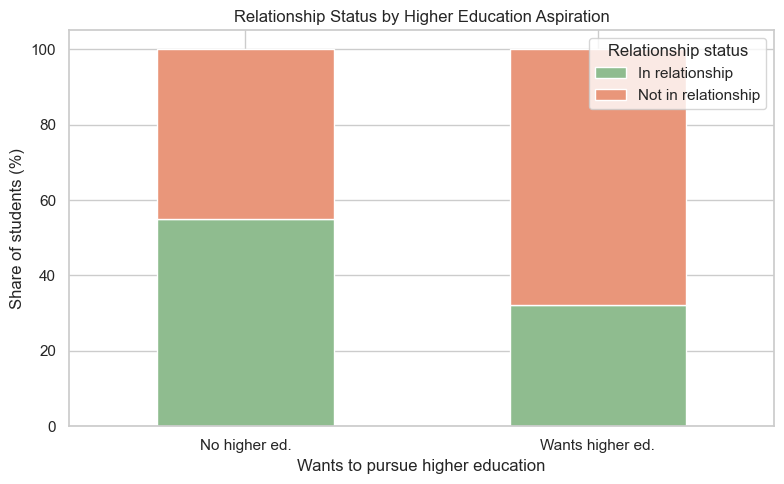

In [12]:
labels = {"higher": {0: "No higher ed.", 1: "Wants higher ed."},
          "romantic": {0: "Not in relationship", 1: "In relationship"}}

contingency = pd.crosstab(df["higher"].map(labels["higher"]), df["romantic"].map(labels["romantic"]))
print("Observed counts:")
display(contingency)

chi2, p_val_3, dof, expected = stats.chi2_contingency(contingency, correction=False)
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)
print("Expected counts under independence:")
display(expected_df.round(2))

print(f"Minimum expected count: {expected.min():.2f} (rule of thumb: >= 5)")

row_pct = contingency.div(contingency.sum(axis=1), axis=0) * 100
ax = row_pct.plot(kind="bar", stacked=True, figsize=(8, 5), color=["#8fbc8f", "#e9967a"])
ax.set_title("Relationship Status by Higher Education Aspiration")
ax.set_xlabel("Wants to pursue higher education")
ax.set_ylabel("Share of students (%)")
ax.legend(title="Relationship status")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 4.2 Test

In [13]:
# Pearson chi-square (no continuity correction) and Yates-corrected version for the 2x2 table
chi2_c, p_c, _, _ = stats.chi2_contingency(contingency, correction=True)
n_total = contingency.to_numpy().sum()
cramers_v = np.sqrt(chi2 / (n_total * (min(contingency.shape) - 1)))

print("=== TEST 3: Chi-square test of independence ===")
print(f"Chi-square statistic: {chi2:.4f} (df = {dof})")
print(f"p-value:              {p_val_3:.4g}")
print(f"Cramer's V:           {cramers_v:.4f}")
print(f"Decision:             {decision(p_val_3)}")
print()
print(f"With Yates continuity correction: chi2 = {chi2_c:.4f}, {decision(p_c)}")

=== TEST 3: Chi-square test of independence ===
Chi-square statistic: 4.4102 (df = 1)
p-value:              0.03573
Cramer's V:           0.1057
Decision:             p = 0.03573 < 0.05: reject H0

With Yates continuity correction: chi2 = 3.4476, p = 0.06334 >= 0.05: fail to reject H0


In [14]:
# Robustness check: Fisher's exact test (exact p-value, no large-sample approximation)
odds_ratio, fisher_p = stats.fisher_exact(contingency.to_numpy())
print("=== Fisher's exact test (2x2) ===")
print(f"Odds ratio: {odds_ratio:.4f}")
print(f"p-value:    {fisher_p:.4g}")
print(f"Decision:   {decision(fisher_p)}")

=== Fisher's exact test (2x2) ===
Odds ratio: 2.5657
p-value:    0.04973
Decision:   p = 0.04973 < 0.05: reject H0


**Interpretation:** the Pearson chi-square test rejects independence (p is about 0.036), but the result is **borderline and fragile**: Fisher's exact test gives p of about 0.0497 (just below 0.05), and the Yates-corrected test does not reject H0 (p is about 0.063). Cramer's V is about 0.11, a weak association. Only 20 students do not want higher education, and a larger share of them is in a relationship (55% vs 32%), so the evidence for dependence is weak and should be reported with that caveat.

## 5. Summary of Results

In [15]:
summary = pd.DataFrame([
    {
        "test": "1. One-sample t-test (G3 vs 10)",
        "statistic": t_stat,
        "p_value": p_val_1,
        "effect_size": f"d = {cohens_d_1:.3f}",
        "decision": "Reject H0" if p_val_1 < ALPHA else "Fail to reject H0",
        "robustness_p": wilcoxon_p,
    },
    {
        "test": "2. Welch t-test (urban vs rural G3)",
        "statistic": res_2.statistic,
        "p_value": res_2.pvalue,
        "effect_size": f"d = {d_2:.3f}",
        "decision": "Reject H0" if res_2.pvalue < ALPHA else "Fail to reject H0",
        "robustness_p": mw_p,
    },
    {
        "test": "3. Chi-square (higher vs romantic)",
        "statistic": chi2,
        "p_value": p_val_3,
        "effect_size": f"V = {cramers_v:.3f}",
        "decision": "Reject H0" if p_val_3 < ALPHA else "Fail to reject H0",
        "robustness_p": fisher_p,
    },
]).set_index("test")

summary["p_value"] = summary["p_value"].map(lambda v: f"{v:.4g}")
summary["robustness_p"] = summary["robustness_p"].map(lambda v: f"{v:.4g}")
summary["statistic"] = summary["statistic"].round(3)
summary

,statistic,p_value,effect_size,decision,robustness_p
test,,,,,
1. One-sample t-test (G3 vs 10),1.801,0.07245,d = 0.091,Fail to reject H0,0.001286
2. Welch t-test (urban vs rural G3),2.110,0.03661,d = 0.255,Reject H0,0.01776
3. Chi-square (higher vs romantic),4.410,0.03573,V = 0.106,Reject H0,0.04973


**Notes**
- `robustness_p` is the p-value of the non-parametric alternative (Wilcoxon, Mann-Whitney U, Fisher's exact test respectively).
- With three tests, a Bonferroni-adjusted threshold would be 0.05 / 3 = 0.0167. Neither Test 2 (p is about 0.037) nor Test 3 (p is about 0.036) would remain significant at that stricter level, so both findings should be treated as suggestive rather than conclusive.
- A statistically significant result is not necessarily practically important: always read the p-value together with the effect size.
- The three hypotheses were chosen after the exploratory analysis in notebook 01, which already showed these group differences (section 6.5). The p-values are therefore optimistic, and the results should be treated as exploratory.